# 01 Data Understanding

Bu notebook'un amacı veri setini anlamak ve tez anlatısı için temel veri keşfini yapmaktır.

Bu notebook'ta:
- veri dosyaları yüklenir
- boyut, kolon yapısı ve eksik değerler incelenir
- ürün, kategori ve kullanıcı etkileşim dağılımları görselleştirilir
- preprocessing kararı verebilmek için ilk gözlemler çıkarılır


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path("..").resolve()
DATA_RAW = PROJECT_ROOT / "data_raw"

products = pd.read_csv(DATA_RAW / "product_info.csv")

review_files = sorted(DATA_RAW.glob("reviews_*.csv"))
reviews = pd.concat((pd.read_csv(path) for path in review_files), ignore_index=True)

print("Products shape:", products.shape)
print("Reviews shape:", reviews.shape)


/var/folders/tm/wc8rn0xj05v33kkcby8sf0fm0000gn/T/ipykernel_54968/2517633986.py:15: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews = pd.concat((pd.read_csv(path) for path in review_files), ignore_index=True)
/var/folders/tm/wc8rn0xj05v33kkcby8sf0fm0000gn/T/ipykernel_54968/2517633986.py:15: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews = pd.concat((pd.read_csv(path) for path in review_files), ignore_index=True)


Products shape: (8494, 27)
Reviews shape: (1094411, 19)


/var/folders/tm/wc8rn0xj05v33kkcby8sf0fm0000gn/T/ipykernel_54968/2517633986.py:15: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews = pd.concat((pd.read_csv(path) for path in review_files), ignore_index=True)


In [2]:
display(products.head())
display(reviews.head())

print("Products columns:")
display(pd.DataFrame({"column": products.columns, "dtype": products.dtypes.astype(str)}))

print("Reviews columns:")
display(pd.DataFrame({"column": reviews.columns, "dtype": reviews.dtypes.astype(str)}))


,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.6364,11.0,NaN,NaN,NaN,...,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
1,P473668,La Habana Eau de Parfum,6342,19-69,3827,4.1538,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,85.0,30.0
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253,4.2500,16.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
3,P473660,Kasbah Eau de Parfum,6342,19-69,3018,4.4762,21.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
4,P473658,Purple Haze Eau de Parfum,6342,19-69,2691,3.2308,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0


,Unnamed: 0,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd
0,0,1741593524,5,1.0,1.0,2,0,2,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,Taught me how to double cleanse!,NaN,brown,dry,black,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,19.0
1,1,31423088263,1,0.0,NaN,0,0,0,2023-03-21,I bought this lip mask after reading the revie...,Disappointed,NaN,NaN,NaN,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
2,2,5061282401,5,1.0,NaN,0,0,0,2023-03-21,My review title says it all! I get so excited ...,New Favorite Routine,light,brown,dry,blonde,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
3,3,6083038851,5,1.0,NaN,0,0,0,2023-03-20,I’ve always loved this formula for a long time...,Can't go wrong with any of them,NaN,brown,combination,black,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
4,4,47056667835,5,1.0,NaN,0,0,0,2023-03-20,"If you have dry cracked lips, this is a must h...",A must have !!!,light,hazel,combination,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0


Products columns:


,column,dtype
product_id,product_id,object
product_name,product_name,object
brand_id,brand_id,int64
brand_name,brand_name,object
loves_count,loves_count,int64
rating,rating,float64
reviews,reviews,float64
size,size,object
variation_type,variation_type,object
variation_value,variation_value,object


Reviews columns:


,column,dtype
Unnamed: 0,Unnamed: 0,int64
author_id,author_id,object
rating,rating,int64
is_recommended,is_recommended,float64
helpfulness,helpfulness,float64
total_feedback_count,total_feedback_count,int64
total_neg_feedback_count,total_neg_feedback_count,int64
total_pos_feedback_count,total_pos_feedback_count,int64
submission_time,submission_time,object
review_text,review_text,object


,column,missing_pct
0,sale_price_usd,96.821286
1,value_price_usd,94.690370
2,variation_desc,85.283730
3,child_max_price,67.577113
4,child_min_price,67.577113
5,highlights,25.983047
6,size,19.201789
7,variation_value,18.813280
8,variation_type,17.000235
9,tertiary_category,11.655286


,column,missing_pct
0,helpfulness,51.314543
1,review_title,28.385497
2,hair_color,20.720552
3,eye_color,19.154413
4,skin_tone,15.582720
5,is_recommended,15.349626
6,skin_type,10.193337
7,review_text,0.131943
8,brand_name,0.000000
9,product_name,0.000000


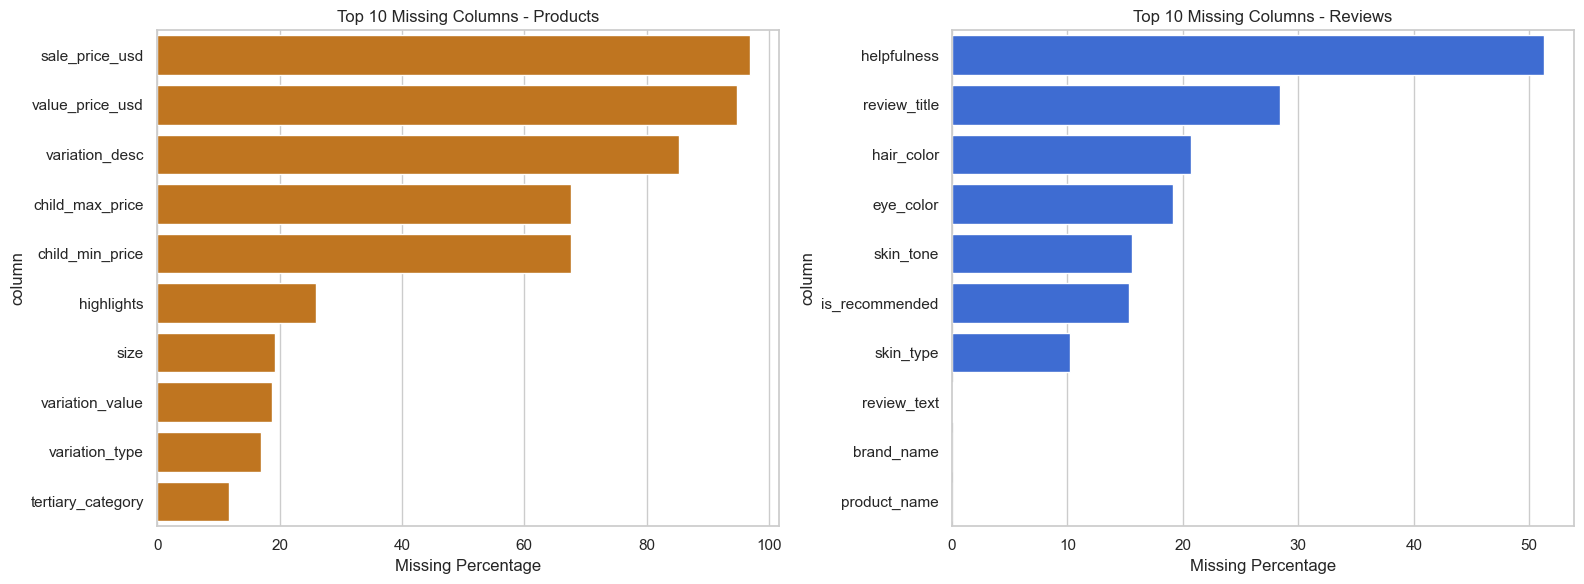

In [3]:
product_missing = (
    products.isna().mean().mul(100).sort_values(ascending=False).reset_index()
    .rename(columns={"index": "column", 0: "missing_pct"})
)
review_missing = (
    reviews.isna().mean().mul(100).sort_values(ascending=False).reset_index()
    .rename(columns={"index": "column", 0: "missing_pct"})
)

display(product_missing.head(15))
display(review_missing.head(15))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=product_missing.head(10), x="missing_pct", y="column", ax=axes[0], color="#D97706")
axes[0].set_title("Top 10 Missing Columns - Products")
axes[0].set_xlabel("Missing Percentage")

sns.barplot(data=review_missing.head(10), x="missing_pct", y="column", ax=axes[1], color="#2563EB")
axes[1].set_title("Top 10 Missing Columns - Reviews")
axes[1].set_xlabel("Missing Percentage")
plt.tight_layout()


## Grafik Yorumu

Bu görsel ürün ve yorum tablolarındaki eksik veri problemlerinin hangi sütunlarda yoğunlaştığını göstermektedir. Tezde bu bölüm, hangi değişkenlerin model dışında bırakıldığı ve hangi alanların temizleme işlemine dahil edildiği kararını gerekçelendirmek için kullanılabilir.

Örnek tez cümlesi:
"Eksik değer analizi sonucunda özellikle bazı fiyat ve varyasyon alanlarında yüksek oranda eksiklik bulunduğu görülmüş, bu nedenle öneri kalitesine sınırlı katkı sağlayacak sütunlar veri ön işleme aşamasında veri setinden çıkarılmıştır."


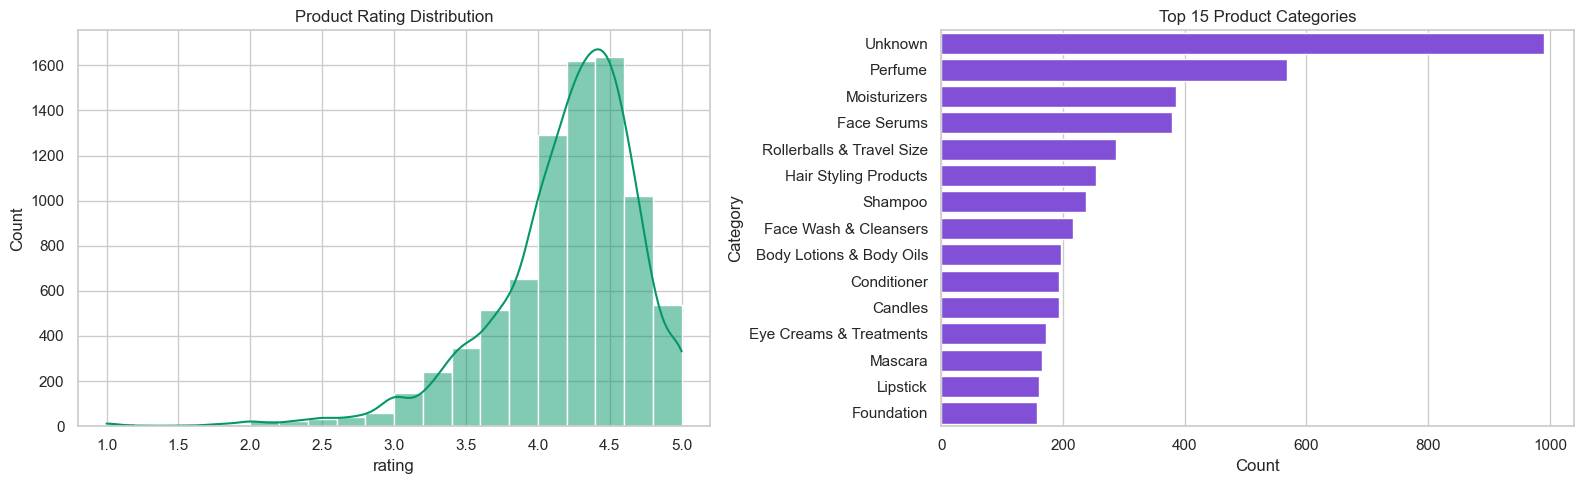

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(products["rating"].dropna(), bins=20, kde=True, ax=axes[0], color="#059669")
axes[0].set_title("Product Rating Distribution")

sns.countplot(
    y=products["tertiary_category"].fillna("Unknown"),
    order=products["tertiary_category"].fillna("Unknown").value_counts().head(15).index,
    ax=axes[1],
    color="#7C3AED"
)
axes[1].set_title("Top 15 Product Categories")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Category")
plt.tight_layout()


## Grafik Yorumu

Rating dağılımı ürünlerin genel olarak yüksek puan aldığını, kategori dağılımı ise veri setinin bazı ürün gruplarında yoğunlaştığını göstermektedir. Bu durum hem öneri sisteminde popüler kategorilere doğru doğal bir eğilim oluşabileceğini hem de evaluation sırasında kategori bazlı incelemenin gerekli olduğunu düşündürmektedir.


,author_id,interaction_count
0,1696370280,292
1,1288462295,210
2,1930716686,155
3,7375781965,155
4,2330399812,151


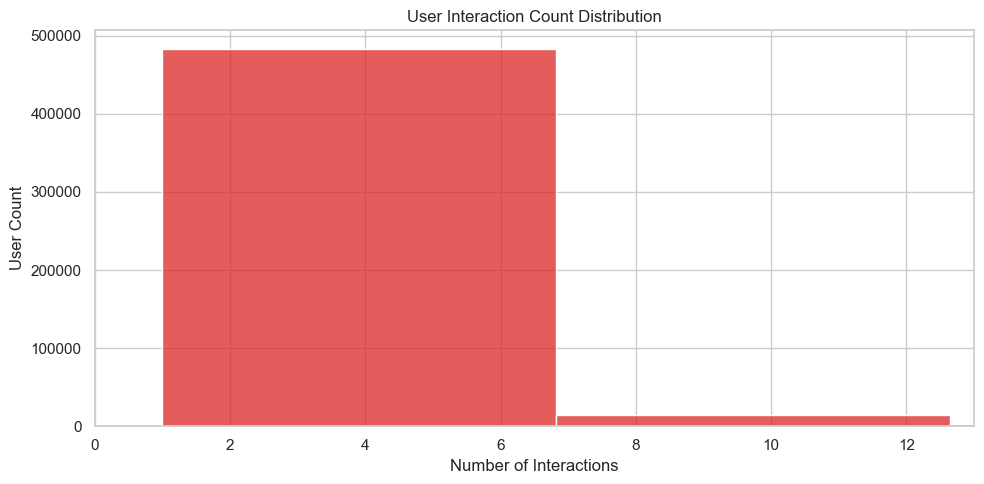

In [5]:
reviews["author_id"] = reviews["author_id"].astype(str)
user_interactions = (
    reviews.groupby("author_id")["product_id"].count().sort_values(ascending=False).reset_index()
    .rename(columns={"product_id": "interaction_count"})
)

display(user_interactions.head())

plt.figure(figsize=(10, 5))
sns.histplot(user_interactions["interaction_count"], bins=50, color="#DC2626")
plt.title("User Interaction Count Distribution")
plt.xlabel("Number of Interactions")
plt.ylabel("User Count")
plt.xlim(0, user_interactions["interaction_count"].quantile(0.99))
plt.tight_layout()


## Grafik Yorumu

Kullanıcı etkileşim dağılımı belirgin biçimde dengesizdir; çok sayıda kullanıcı az sayıda etkileşime sahipken daha küçük bir kullanıcı grubu oldukça yoğun etkileşim üretmektedir. Bu gözlem collaborative filtering aşamasında minimum etkileşim eşiği kullanılmasını desteklemektedir.

Örnek tez cümlesi:
"Kullanıcı başına etkileşim sayıları incelendiğinde dağılımın sağa çarpık olduğu gözlenmiştir. Bu nedenle evaluation aşamasında anlamlı kullanıcı geçmişi bulunan bireyleri seçebilmek için minimum etkileşim filtresi uygulanmıştır."


## Summary

Bu notebook sonunda tezde kullanılacak veri problemleri netleştirilmelidir:
- hangi kolonlar tutulacak
- hangi kolonlar çıkarılacak
- eksik değer stratejisi ne olacak
- evaluation için kullanıcı filtreleme eşiği ne olacak
